<a href="https://colab.research.google.com/github/uguazelli/scikit_learn/blob/main/logistic_regression101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install seaborn scikit-learn matplotlib pandas

In [3]:
# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
# Step 2: Load Titanic dataset from seaborn
df = sns.load_dataset("titanic")

In [5]:
# Step 3: Preprocess data
# Keep relevant columns
df = df[["survived", "sex", "age", "fare", "pclass", "embarked"]].dropna()

# Convert categorical to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Define features and target
X = df.drop("survived", axis=1)
y = df["survived"]

In [6]:
# Step 4: Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Step 5: Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Accuracy: 0.7902097902097902

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.91      0.83        80
           1       0.85      0.63      0.73        63

    accuracy                           0.79       143
   macro avg       0.81      0.77      0.78       143
weighted avg       0.80      0.79      0.78       143



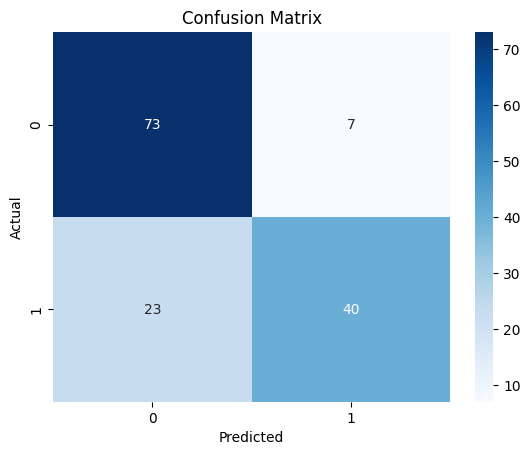

In [8]:
# Step 6: Evaluate model
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Predict
# Column order: ['sex', 'age', 'fare', 'pclass', 'embarked']
import numpy as np

# Prepare the input
new_passenger = np.array([[1, 28, 35.5, 2, 1]])  # 1 = female, 1 = 'C' embark

# Scale the input using the same scaler used in training
new_passenger_scaled = scaler.transform(new_passenger)

# Predict class
prediction = model.predict(new_passenger_scaled)
print("Prediction:", "Survived" if prediction[0] == 1 else "Did NOT survive")

# Predict probability
prob = model.predict_proba(new_passenger_scaled)
print(f"Probability of NOT surviving: {prob[0][0]:.2f}")
print(f"Probability of surviving: {prob[0][1]:.2f}")


Prediction: Survived
Probability of NOT surviving: 0.18
Probability of surviving: 0.82


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
